In [1]:
# SETUP
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show
from scipy import stats

In [2]:
POWERLIFTING_PATH = '../datasets/cleaned_openpowerlifting.csv'
pl = pd.read_csv(POWERLIFTING_PATH, low_memory=False)
pl

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Tested,Federation,Year,Group
0,F,43.5,73.2,NaN,90.0,NaN,90.0,1,88.80,86.89,NaN,GSF-Belarus,2019,Unknown
1,F,26.5,60.6,NaN,45.0,NaN,45.0,2,49.57,49.79,NaN,GSF-Belarus,2019,Unknown
2,F,19.5,50.3,NaN,35.0,NaN,35.0,2,43.67,44.76,NaN,GSF-Belarus,2019,Unknown
3,F,19.5,63.7,NaN,42.5,NaN,42.5,1,45.40,45.26,NaN,GSF-Belarus,2019,Unknown
4,M,30.5,82.0,NaN,132.5,NaN,132.5,2,90.07,89.09,NaN,GSF-Belarus,2019,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3661402,M,17.0,64.4,177.5,120.0,215.0,512.5,1,409.03,410.73,Yes,SSSC,2022,Natural
3661403,M,17.0,82.9,212.5,112.5,230.0,555.0,1,374.93,370.73,Yes,SSSC,2022,Natural
3661404,M,17.0,91.3,242.5,130.0,257.5,630.0,1,404.46,399.31,Yes,SSSC,2022,Natural
3661405,M,18.0,103.6,215.0,120.0,255.0,590.0,1,357.78,354.25,Yes,SSSC,2022,Natural


In [3]:
# solo gare in cui si hanno fatto tutte e tre le categorie
pl_SBD = pl.dropna(subset=['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg'])
pl_SBD

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Tested,Federation,Year,Group
309,M,NaN,38.8,50.0,25.0,70.0,145.0,1,184.31,193.64,NaN,WPC-Latvia,2011,Unknown
310,M,NaN,42.8,35.0,30.0,75.0,140.0,1,164.28,171.54,NaN,WPC-Latvia,2011,Unknown
311,M,NaN,47.0,50.0,40.0,80.0,170.0,1,180.07,186.35,NaN,WPC-Latvia,2011,Unknown
312,M,NaN,51.7,55.0,35.0,95.0,185.0,1,178.17,182.64,NaN,WPC-Latvia,2011,Unknown
313,M,NaN,52.8,55.0,40.0,107.5,202.5,1,191.19,195.58,NaN,WPC-Latvia,2011,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3661402,M,17.0,64.4,177.5,120.0,215.0,512.5,1,409.03,410.73,Yes,SSSC,2022,Natural
3661403,M,17.0,82.9,212.5,112.5,230.0,555.0,1,374.93,370.73,Yes,SSSC,2022,Natural
3661404,M,17.0,91.3,242.5,130.0,257.5,630.0,1,404.46,399.31,Yes,SSSC,2022,Natural
3661405,M,18.0,103.6,215.0,120.0,255.0,590.0,1,357.78,354.25,Yes,SSSC,2022,Natural


In [4]:
naturals_SBD = pl_SBD[ pl_SBD['Group'] == 'Natural' ]
unknown_SBD  = pl_SBD[ pl_SBD['Group'] == 'Unknown' ]

In [5]:
# colori
colori = {'Natural': '#4e9a6f', 'Unknown': '#708090'}

<style>
    
.reveal .output_png {
    display: table-cell !important;
    text-align: center !important;
    vertical-align: middle !important;
}
.reveal .output_subarea {
    display: flex !important;
    justify-content: center !important;
    align-items: center !important;
}
.reveal h1, .reveal h2, .reveal h3, .reveal p, .reveal li {
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif !important;
}
.reveal h1 {
    font-weight: 800 !important;
    color: #2b2d42 !important;
    text-transform: none !important;
    letter-spacing: -1px !important;
    border-bottom: 5px solid #ef233c !important;
    display: inline-block !important;
    padding-bottom: 10px !important;
    margin-bottom: 40px !important;
}
.reveal h2 {
    color: #8d99ae !important;
    font-weight: 600 !important;
    font-size: 1.3em !important;
}
.reveal strong {
    color: #d90429 !important;
    font-weight: 800 !important;
}
.reveal blockquote {
    background: #edf2f4 !important;
    border-left: 8px solid #2b2d42 !important;
    margin: 30px auto !important;
    padding: 25px 30px !important;
    border-radius: 0 10px 10px 0 !important;
    font-style: italic !important;
    font-size: 1.1em !important;
}
#img_powerlifter {
    position: absolute !important;
    top: 50% !important;
    left: 50% !important;
    transform: translate(-50%, -50%) !important;
    width: 450px !important;
    opacity: 0.12 !important;
    z-index: -1 !important;
    border-radius: 20px !important;
    margin: 0 !important;
    pointer-events: none !important;
}

.reveal .output_wrapper, 
.reveal .output_area, 
.reveal .jp-OutputArea-output {
    display: flex !important;
    justify-content: center !important;
    align-items: center !important;
    width: 100% !important;
    text-align: center !important;
}

.reveal .output_png img, 
.reveal .jp-RenderedImage img {
    margin: 0 auto !important;
    display: block !important;
    max-width: 100% !important;
    height: auto !important;
}
</style>

# Differenza tra gare con anti-doping vs gare libere di Powerlifting  

<img id="img_powerlifter" src="../powerlifter.jpeg">

## Un'analisi statistica su 3.6 milioni di gare

Dataset analizzato: OpenPowerLifting (link: https://www.openpowerlifting.org)

Matteo Bruziches (n. matricola: 178139)

# Motivazioni  
Il Powerlifting divide gli atleti in due mondi:  
- Federazioni con **anti-doping** (Natural)
- Fedarazioni **senza** (Unknown)  

# Domande poste:  
- **Esiste** una differenza misurabile tra gli atleti Natural e quelli Unknown?
- La differenza è **statistica** o solo visiva?
- Il pattern anche **separando per sesso**?
- Il divario è **cresciuto nel tempo**?

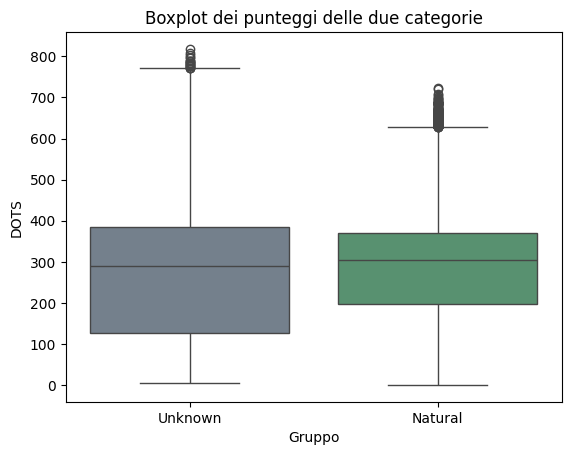

In [6]:
# 2: il problema

# con fallimenti
sns.boxplot(pl, x='Group', y='Dots', hue='Group', palette=colori)

plt.title('Boxplot dei punteggi delle due categorie')
plt.xlabel('Gruppo')
plt.ylabel('DOTS')

plt.show()

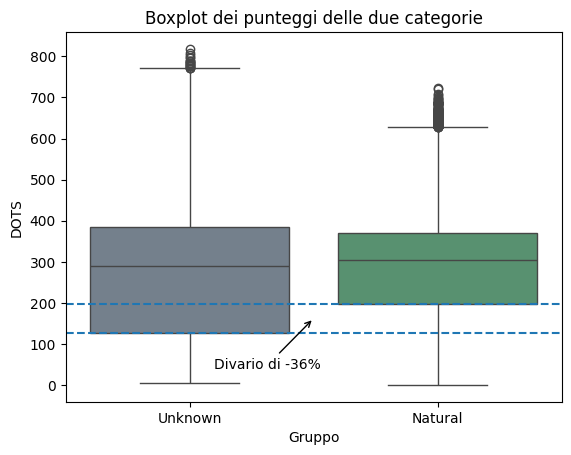

In [7]:
sns.boxplot(pl, x='Group', y='Dots', hue='Group', palette=colori)

plt.title('Boxplot dei punteggi delle due categorie')
plt.xlabel('Gruppo')
plt.ylabel('DOTS')

q1_unk = pl[ pl['Group'] == 'Unknown' ]['Dots'].quantile(.25)
q1_nat = pl[ pl['Group'] == 'Natural' ]['Dots'].quantile(.25)

divario_percentuale = ((q1_unk - q1_nat) / q1_nat) * 100
meta_divario = (q1_unk + q1_nat) / 2

plt.axhline(y=q1_unk, linestyle='--')
plt.axhline(y=q1_nat, linestyle='--')
plt.annotate(
    xy=(.5, meta_divario), xytext=(.1, 40), 
    text=f'Divario di {divario_percentuale:.0f}%',
    arrowprops=dict(arrowstyle='->')
)

plt.show()

# Punto al divario e all'anomalia della coda degli Unknown che cade molto più in basso dei natural

Probabilmente, essendo gare meno controllate, ci sono regole molto più permissive.  
C'è molta più varietà, e vengono registrati tutti i fallimenti, mentre in quelle natural, che sono più serie, non lo fanno  


In [8]:
pl_bassi = pl[ pl['Dots'] < 300 ]
pl_bassi

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Tested,Federation,Year,Group
0,F,43.5,73.2,NaN,90.0,NaN,90.0,1,88.80,86.89,NaN,GSF-Belarus,2019,Unknown
1,F,26.5,60.6,NaN,45.0,NaN,45.0,2,49.57,49.79,NaN,GSF-Belarus,2019,Unknown
2,F,19.5,50.3,NaN,35.0,NaN,35.0,2,43.67,44.76,NaN,GSF-Belarus,2019,Unknown
3,F,19.5,63.7,NaN,42.5,NaN,42.5,1,45.40,45.26,NaN,GSF-Belarus,2019,Unknown
4,M,30.5,82.0,NaN,132.5,NaN,132.5,2,90.07,89.09,NaN,GSF-Belarus,2019,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3661346,F,34.0,66.0,97.5,55.0,130.0,282.5,6,295.49,293.06,Yes,SSSC,2022,Natural
3661347,F,29.0,68.4,60.0,32.5,110.0,202.5,7,207.48,204.74,Yes,SSSC,2022,Natural
3661350,F,27.0,82.2,110.0,45.0,127.5,282.5,1,262.66,254.73,Yes,SSSC,2022,Natural
3661353,F,32.0,110.1,130.0,55.0,140.0,325.0,3,267.82,264.20,Yes,SSSC,2022,Natural


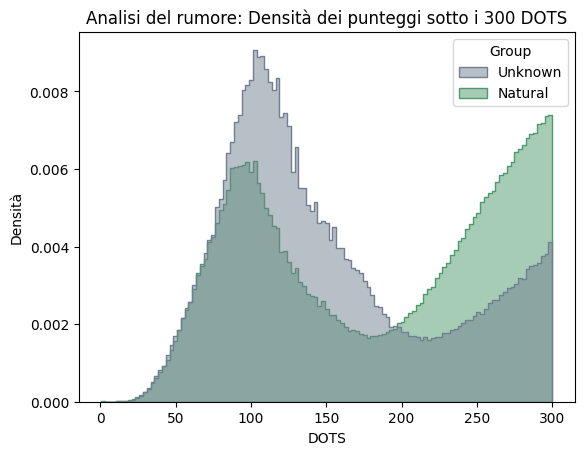

In [9]:
# 3: esplorazione

sns.histplot(
    pl_bassi,
    x='Dots',
    hue='Group',
    element='step',
    stat='density',
    common_norm=False,
    palette=colori,
    alpha=.5
)

plt.title('Analisi del rumore: Densità dei punteggi sotto i 300 DOTS')
plt.xlabel('DOTS')
plt.ylabel('Densità')

plt.show()

Sotto ai 200 DOTS, la densità degli unknown è molto più alta dei natural. Perché?  

Cause probabili:  
- più varietà di età (compresi bambini e anziani over 70)
- più gare incomplete

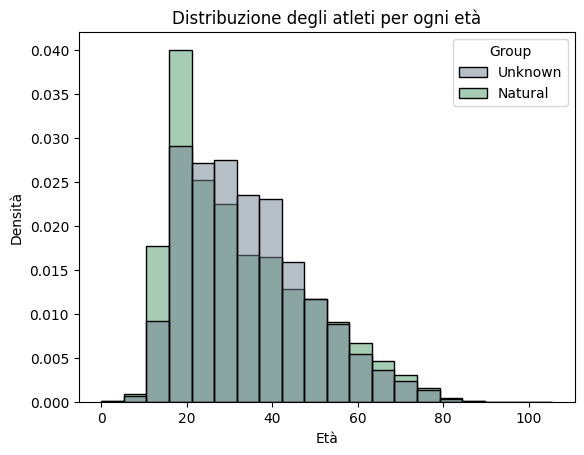

In [10]:
# 4: ipotesi età (smentita)

sns.histplot(pl_bassi, x='Age', hue='Group', bins=20, palette=colori, edgecolor='black', stat='density', common_norm=False)

plt.title('Distribuzione degli atleti per ogni età')
plt.xlabel('Età')
plt.ylabel('Densità')

plt.show()

Inizialmente ho ipotizzato che il fondo del gruppo Unknown fosse causato da anomalie anagrafiche (giovanissimi o master). Tuttavia, l'analisi dei conteggi ha smentito l'ipotesi, mostrando distribuzioni dell'età sovrapponibili

IPOTESI: Le gare unknown hanno molte più gare con una singola categoria in confronto a quelle natural, che di solito le fanno tutte e tre

In [11]:
# vediamo quante gare complete hanno gli unknown e i natural

pl['Gara'] = np.where(
    pl['Best3SquatKg'].notna() & pl['Best3BenchKg'].notna() & pl['Best3DeadliftKg'].notna(),
    'Completa',
    'Incompleta'
)
pl

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Tested,Federation,Year,Group,Gara
0,F,43.5,73.2,NaN,90.0,NaN,90.0,1,88.80,86.89,NaN,GSF-Belarus,2019,Unknown,Incompleta
1,F,26.5,60.6,NaN,45.0,NaN,45.0,2,49.57,49.79,NaN,GSF-Belarus,2019,Unknown,Incompleta
2,F,19.5,50.3,NaN,35.0,NaN,35.0,2,43.67,44.76,NaN,GSF-Belarus,2019,Unknown,Incompleta
3,F,19.5,63.7,NaN,42.5,NaN,42.5,1,45.40,45.26,NaN,GSF-Belarus,2019,Unknown,Incompleta
4,M,30.5,82.0,NaN,132.5,NaN,132.5,2,90.07,89.09,NaN,GSF-Belarus,2019,Unknown,Incompleta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3661402,M,17.0,64.4,177.5,120.0,215.0,512.5,1,409.03,410.73,Yes,SSSC,2022,Natural,Completa
3661403,M,17.0,82.9,212.5,112.5,230.0,555.0,1,374.93,370.73,Yes,SSSC,2022,Natural,Completa
3661404,M,17.0,91.3,242.5,130.0,257.5,630.0,1,404.46,399.31,Yes,SSSC,2022,Natural,Completa
3661405,M,18.0,103.6,215.0,120.0,255.0,590.0,1,357.78,354.25,Yes,SSSC,2022,Natural,Completa


In [12]:
# crosstab conta quante gare complete/incomplete hanno fatto i natural/unknown
# normalize='index' fa in modo che ogni riga venga normalizzata singolarmente
tabella_proporzioni = pd.crosstab(pl['Group'], pl['Gara'], normalize='index') * 100
tabella_proporzioni

Gara,Completa,Incompleta
Group,,
Natural,76.053027,23.946973
Unknown,57.759197,42.240803


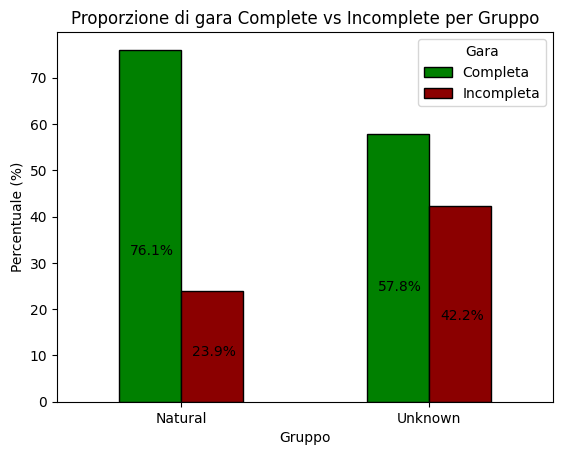

In [13]:
# 5: vera causa (gare incomplete)

colori_gara = {'Incompleta': 'darkred', 'Completa': 'green'}

ax = tabella_proporzioni.plot(
    kind='bar',
    stacked=False,
    color=colori_gara,
    edgecolor='black'
)

plt.title('Proporzione di gara Complete vs Incomplete per Gruppo')
plt.xlabel('Gruppo')
plt.ylabel('Percentuale (%)')
# xticks per ruotare i label in x
plt.xticks(rotation=0)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text( x + .045, y + height/2.4, f'{height:.1f}%' )

plt.show()

La percentuale di gare complete nei Natural è del 76.1%, mentre per gli unknown è del 57.8%

Per validare definitivamente la mia seconda ipotesi, ho creato un grafico a barre normalizzato al 100%. Come si evince chiaramente, il gruppo Unknown presenta una quota significativamente maggiore di competizioni incomplete o single-lift rispetto ai Natural. Questo conferma che l'anomalia riscontrata nel primo boxplot non era un dato biologico, ma un artefatto strutturale del dataset, che giustifica ex-post la mia decisione di operare un data filtering basato sulle sole gare complete.

In [14]:
# 6: Calcolo soglia statistica (Z-index)

natural_DOTS = pl_SBD[ pl_SBD['Group'] == 'Natural' ]['Dots']
media_nat    = natural_DOTS.mean()
std_nat      = natural_DOTS.std()

limite_umano = media_nat + (std_nat * 3)

print(f'Media natural: {media_nat:.1f} DOTS')
print(f'STD natural:   {std_nat:.1f} DOTS')
print(f'Soglia Z=3:    {limite_umano:.0f} DOTS')

Media natural: 338.0 DOTS
STD natural:   77.6 DOTS
Soglia Z=3:    571 DOTS


In [15]:
# Mann-Whitney U test

pl_competitivi = pl_SBD[pl_SBD['Dots'] >= 350].copy()

nat_dots = pl_competitivi[ pl_competitivi['Group'] == 'Natural' ]['Dots']
unk_dots = pl_competitivi[ pl_competitivi['Group'] == 'Unknown' ]['Dots']

stat, p = stats.mannwhitneyu(nat_dots, unk_dots, alternative='less')

print(f'Mann-Whitney U: p-value = {p:.2e}')
# se è ~0 allora la differenza è statisticamente certa

Mann-Whitney U: p-value = 0.00e+00


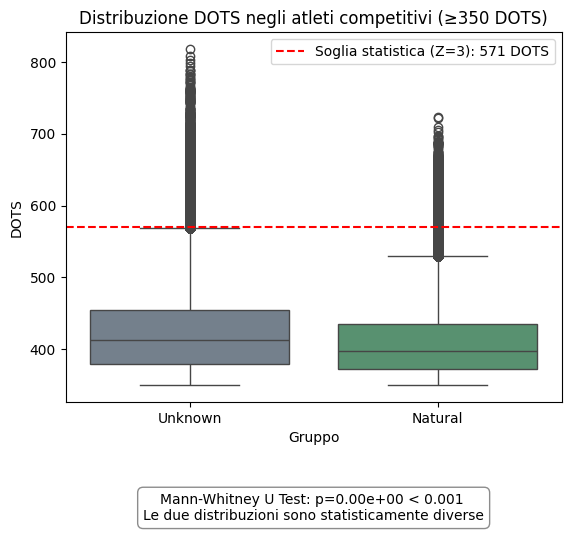

In [16]:
# 7: la verità dopo il filtro

# escludo i fallimenti
sns.boxplot(
    pl_competitivi,
    x='Group',
    y='Dots',
    hue='Group',
    palette=colori
)

plt.axhline(
    y=limite_umano,
    color='red',
    linestyle='--',
    label=f'Soglia statistica (Z=3): {limite_umano:.0f} DOTS'
)

plt.title('Distribuzione DOTS negli atleti competitivi (≥350 DOTS)')
plt.xlabel('Gruppo')
plt.ylabel('DOTS')
plt.legend(loc='upper right')
plt.text(
    .5, 200,
    f'Mann-Whitney U Test: p={p:.2e} < 0.001 \nLe due distribuzioni sono statisticamente diverse',
    ha='center',
    va='top',
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray', alpha=0.9)
)

plt.show()

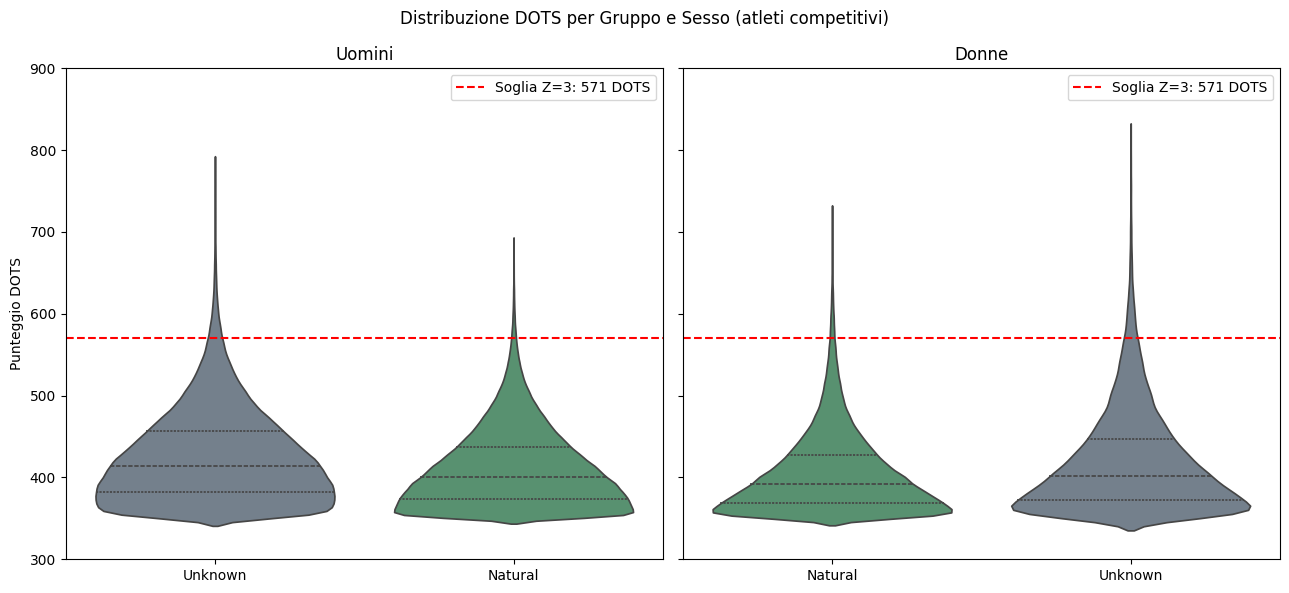

In [26]:
# 8: violin plot diviso per sessi

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

# zip unisce axes[0] con ('M', 'Uomini') e axes[1] con ('F', 'Donne')
for ax, (sex, label) in zip(axes, [('M', 'Uomini'), ('F', 'Donne')]):
    data_sex = pl_competitivi[ pl_competitivi['Sex'] == sex ]

    sns.violinplot(
        data=data_sex,
        x='Group', y='Dots',
        hue='Group',
        palette=colori,
        inner='quartile', # mostra media e quartili dentro il violino
        ax=ax
    )

    ax.axhline(
        y=limite_umano, color='red', linestyle='--',
        label=f'Soglia Z=3: {limite_umano:.0f} DOTS'
    )

    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('Punteggio DOTS' if sex == 'M' else '')
    ax.legend()
    ax.set_ylim(300, 900)
    
fig.suptitle('Distribuzione DOTS per Gruppo e Sesso (atleti competitivi)')

plt.tight_layout()
plt.show()

# Guardando il violin plot mi aspettavo lo stesso pattern per entrambi i sessi,
# ma per le donne la situazione è più sfumata. La mediana delle Natural è più alta,
# il che suggerisce che la competizione femminile nelle federazioni Unknown non è mediamente più forte. 
# Tuttavia la coda superiore degli Unknown supera ancora la soglia Z=3,
# indicando che il fenomeno esiste ma è concentrato nelle atlete d'élite

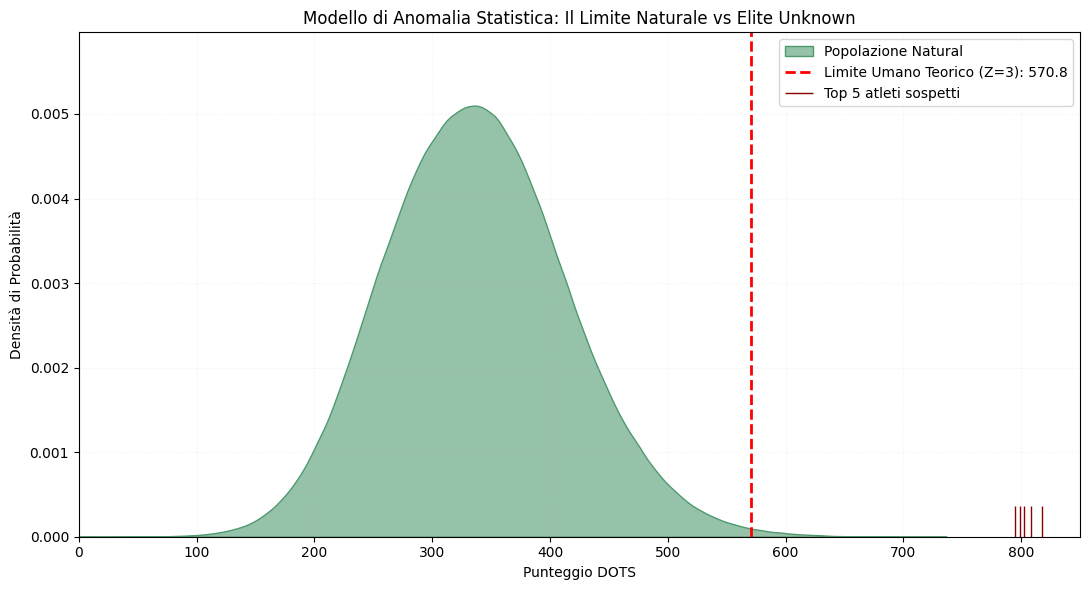

In [25]:
# 9: KDE + outlier più sospetti

sus_unknowns = pl_SBD[ (pl_SBD['Group'] == 'Unknown') & (pl_SBD['Dots'] > limite_umano) ].copy()
sus_unknowns['Z-score'] = (sus_unknowns['Dots'] - media_nat) / std_nat

top5_sus_unknowns = sus_unknowns.sort_values(by='Dots', ascending=False).head(5)

plt.figure(figsize=(11, 6))

sns.kdeplot(
    data=pl_SBD[pl_SBD['Group'] == 'Natural'], 
    x='Dots', 
    fill=True, 
    color='#4e9a6f', 
    alpha=0.6,
    label='Popolazione Natural'
)

plt.axvline(x=limite_umano, color='red', linestyle='--', linewidth=2, label=f'Limite Umano Teorico (Z=3): {limite_umano:.1f}')

sns.rugplot(
    data=top5_sus_unknowns,
    x='Dots',
    height=.06,
    color='darkred',
    label=f'Top {len(top5_sus_unknowns)} atleti sospetti'
)

plt.title("Modello di Anomalia Statistica: Il Limite Naturale vs Elite Unknown")
plt.xlabel("Punteggio DOTS")
plt.ylabel("Densità di Probabilità")
plt.legend(loc='upper right')
plt.xlim(0, 850)
plt.grid(True, alpha=0.15, linestyle=':')

plt.tight_layout()

plt.show()

# Evoluzione nel tempo degli atleti  

I natural raggiungono un soffitto che non si può superare

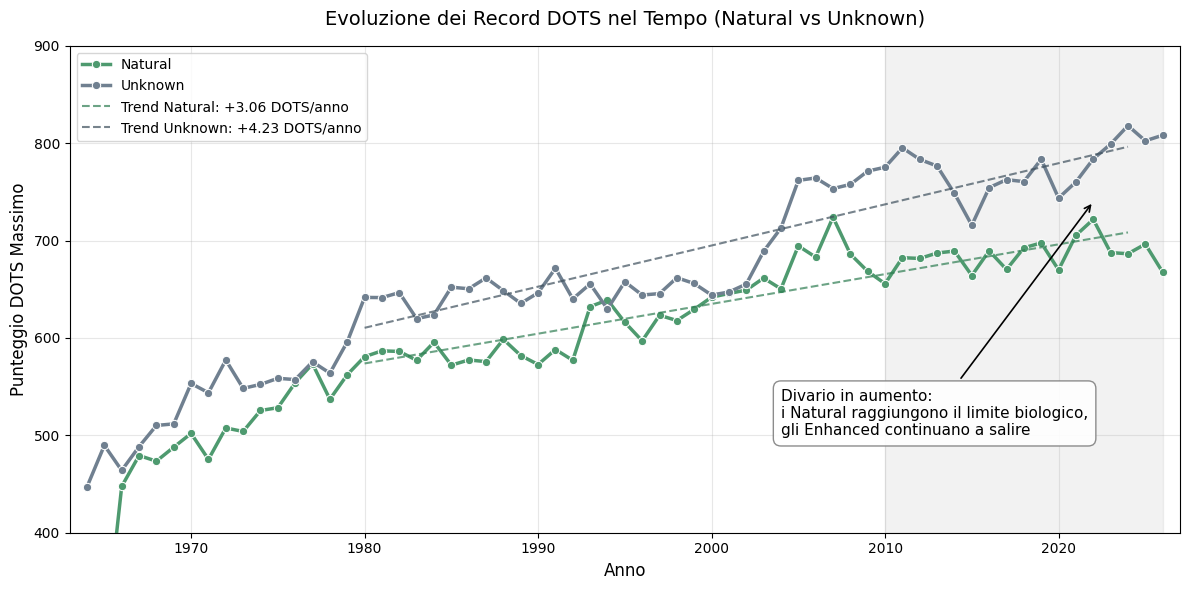

In [22]:
# 10: lineplot con linee di regressione

evo_nat = pl[ (pl['Group'] == 'Natural') ].groupby('Year')['Dots'].max().reset_index()
evo_nat['Group'] = 'Natural'
evo_unk = pl[ (pl['Group'] == 'Unknown') ].groupby('Year')['Dots'].max().reset_index()
evo_unk['Group'] = 'Unknown'

evo_all = pd.concat([evo_nat, evo_unk])

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=evo_all, x='Year', y='Dots', hue='Group',
             marker='o', linewidth=2.5, palette=colori, ax=ax)

# rette di regressione
anni_fit = np.linspace(1980, 2024, 200)

for gruppo, colore in [('Natural', '#2e7d52'), ('Unknown', '#3d4f5c')]:
    dati_g = evo_all[ (evo_all['Group'] == gruppo) & (evo_all['Year'] >= 1980) ]
    slope, intercept, r, p, _ = stats.linregress(dati_g['Year'], dati_g['Dots'])

    ax.plot(
        anni_fit,
        intercept + slope * anni_fit,
        linestyle='--', linewidth=1.5, color=colore, alpha=0.7,
        label=f'Trend {gruppo}: +{slope:.2f} DOTS/anno'
    )

ax.axvspan(2010, 2026, color='gray', alpha=0.1)
ax.annotate(
    'Divario in aumento:\ni Natural raggiungono il limite biologico,\ngli Enhanced continuano a salire',
    xy=(2022, 740), xytext=(2004, 500),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
    fontsize=11,
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.9)
)

ax.set_title('Evoluzione dei Record DOTS nel Tempo (Natural vs Unknown)',
             fontsize=14, pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Punteggio DOTS Massimo', fontsize=12)
ax.set_xlim(1963, 2027)
ax.set_ylim(400, 900)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Conclusioni  
- Il doping produce un vantaggio misurabile (p < 0.001)
- Il rumore era strutturale: era necessario il data auditing
- Il vantaggio farmacologico emerge soprattutto nelle donne a livello d'elite, ma non nella media. Per gli uomini è il contrario
- Il divario cresce nel tempo. I Natural raggiungono un tetto biologico